# Panda Sphere3D Dataset Exploration

Motion planning trajectories for a 7-DOF Franka Panda robot in a 3D sphere obstacle environment.  
**Expert** policy produces collision-free paths; **non-expert** frequently collides.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

sns.set_context('notebook')
DATA_DIR = Path('../data/panda')

## 1. Load all trajectories

In [2]:
def load_all_trajs(policy_dir):
    """Load and concatenate all free/collision trajectories across seeds."""
    free_list, coll_list = [], []
    seeds = sorted([int(x) for x in os.listdir(policy_dir) if x.isdigit()])
    for s in seeds:
        f = torch.load(policy_dir / str(s) / 'trajs-free.pt', map_location='cpu', weights_only=False)
        c = torch.load(policy_dir / str(s) / 'trajs-collision.pt', map_location='cpu', weights_only=False)
        if f.dim() > 1:
            free_list.append(f)
        if c.dim() > 1:
            coll_list.append(c)
    free = torch.cat(free_list) if free_list else torch.zeros(0, 64, 14)
    coll = torch.cat(coll_list) if coll_list else torch.zeros(0, 64, 14)
    return free.numpy(), coll.numpy(), seeds

expert_free, expert_coll, expert_seeds = load_all_trajs(DATA_DIR / 'expert')
nonexp_free, nonexp_coll, nonexp_seeds = load_all_trajs(DATA_DIR / 'non-expert')

print(f'Expert:     {expert_free.shape[0]} free, {expert_coll.shape[0]} collision  ({len(expert_seeds)} seeds)')
print(f'Non-expert: {nonexp_free.shape[0]} free, {nonexp_coll.shape[0]} collision  ({len(nonexp_seeds)} seeds)')
print(f'Trajectory shape: {expert_free.shape[1:]}  (64 waypoints x 14 dims = 7q + 7qdot)')

Expert:     3000 free, 0 collision  (24 seeds)
Non-expert: 427 free, 1573 collision  (20 seeds)
Trajectory shape: (64, 14)  (64 waypoints x 14 dims = 7q + 7qdot)


## 2. Per-seed collision rates

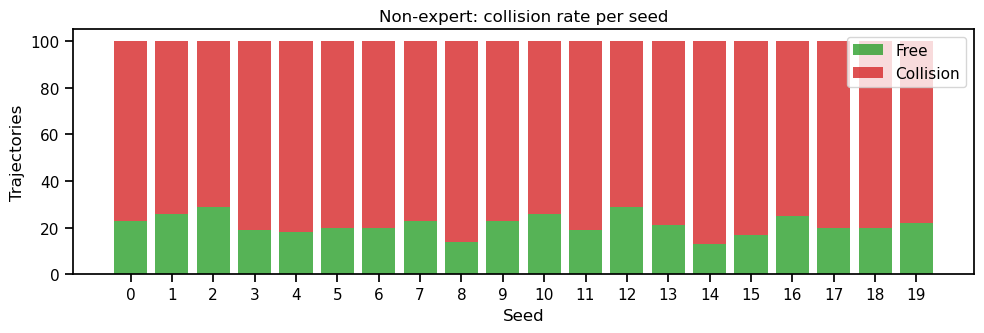

In [3]:
def per_seed_stats(policy_dir):
    seeds = sorted([int(x) for x in os.listdir(policy_dir) if x.isdigit()])
    stats = []
    for s in seeds:
        f = torch.load(policy_dir / str(s) / 'trajs-free.pt', map_location='cpu', weights_only=False)
        c = torch.load(policy_dir / str(s) / 'trajs-collision.pt', map_location='cpu', weights_only=False)
        nf = f.shape[0] if f.dim() > 1 else 0
        nc = c.shape[0] if c.dim() > 1 else 0
        stats.append((s, nf, nc))
    return stats

nonexp_stats = per_seed_stats(DATA_DIR / 'non-expert')
seeds, nf, nc = zip(*nonexp_stats)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(len(seeds)), nf, label='Free', color='tab:green', alpha=0.8)
ax.bar(range(len(seeds)), nc, bottom=nf, label='Collision', color='tab:red', alpha=0.8)
ax.set_xticks(range(len(seeds)))
ax.set_xticklabels(seeds)
ax.set_xlabel('Seed')
ax.set_ylabel('Trajectories')
ax.set_title('Non-expert: collision rate per seed')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Joint trajectories: expert vs non-expert

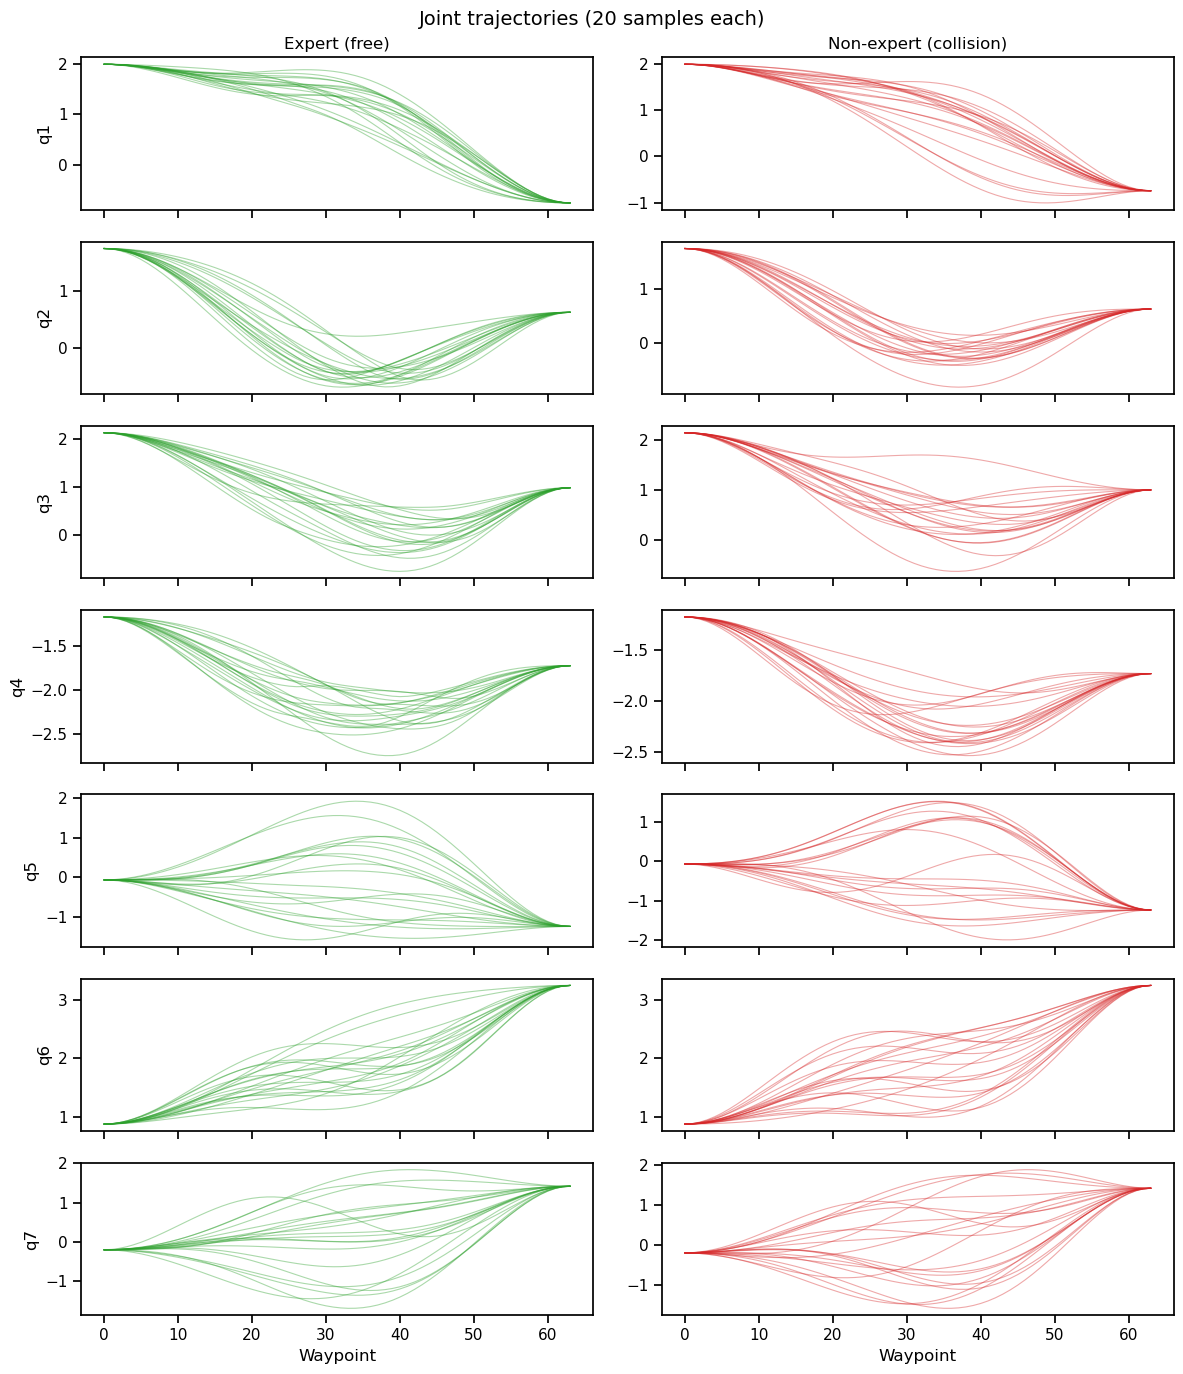

In [4]:
joint_names = [f'q{i+1}' for i in range(7)]
t = np.arange(64)

fig, axes = plt.subplots(7, 2, figsize=(12, 14), sharex=True)
fig.suptitle('Joint trajectories (20 samples each)', fontsize=14)

for j in range(7):
    # Expert free
    ax = axes[j, 0]
    for i in range(min(20, expert_free.shape[0])):
        ax.plot(t, expert_free[i, :, j], alpha=0.4, color='tab:green', lw=0.8)
    ax.set_ylabel(joint_names[j])
    if j == 0:
        ax.set_title('Expert (free)')

    # Non-expert collision
    ax = axes[j, 1]
    for i in range(min(20, nonexp_coll.shape[0])):
        ax.plot(t, nonexp_coll[i, :, j], alpha=0.4, color='tab:red', lw=0.8)
    if j == 0:
        ax.set_title('Non-expert (collision)')

axes[-1, 0].set_xlabel('Waypoint')
axes[-1, 1].set_xlabel('Waypoint')
plt.tight_layout()
plt.show()

## 4. Position deltas (dims 7-13)

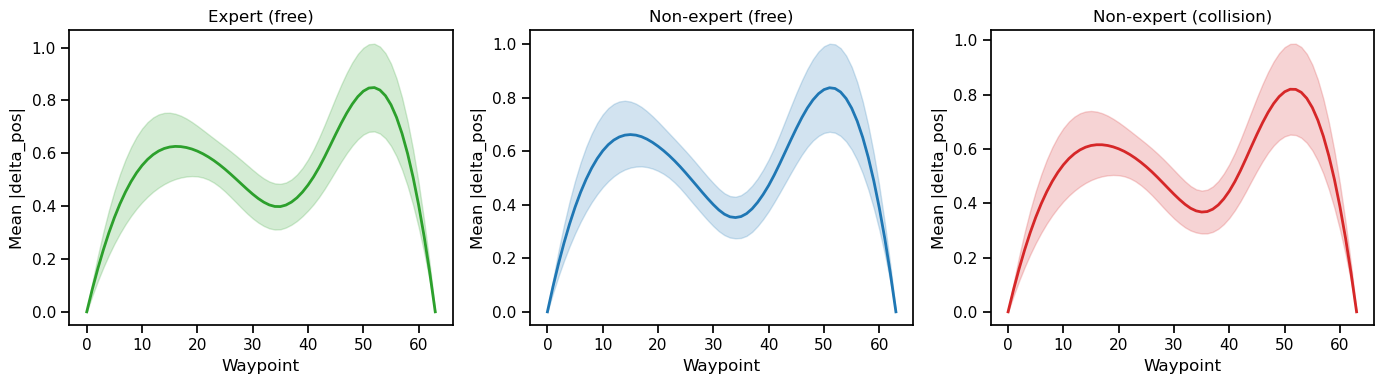

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

labels = ['Expert (free)', 'Non-expert (free)', 'Non-expert (collision)']
datasets = [expert_free, nonexp_free, nonexp_coll]
colors = ['tab:green', 'tab:blue', 'tab:red']

for ax, data, label, c in zip(axes, datasets, labels, colors):
    deltas = data[:, :, 7:]  # position delta dims
    # Per-waypoint mean absolute delta across joints
    mean_abs = np.mean(np.abs(deltas), axis=(0, 2))
    std_abs = np.std(np.mean(np.abs(deltas), axis=2), axis=0)
    ax.fill_between(t, mean_abs - std_abs, mean_abs + std_abs, alpha=0.2, color=c)
    ax.plot(t, mean_abs, color=c, lw=2)
    ax.set_title(label)
    ax.set_xlabel('Waypoint')
    ax.set_ylabel('Mean |delta_pos|')

plt.tight_layout()
plt.show()

## 5. Distribution of joint values

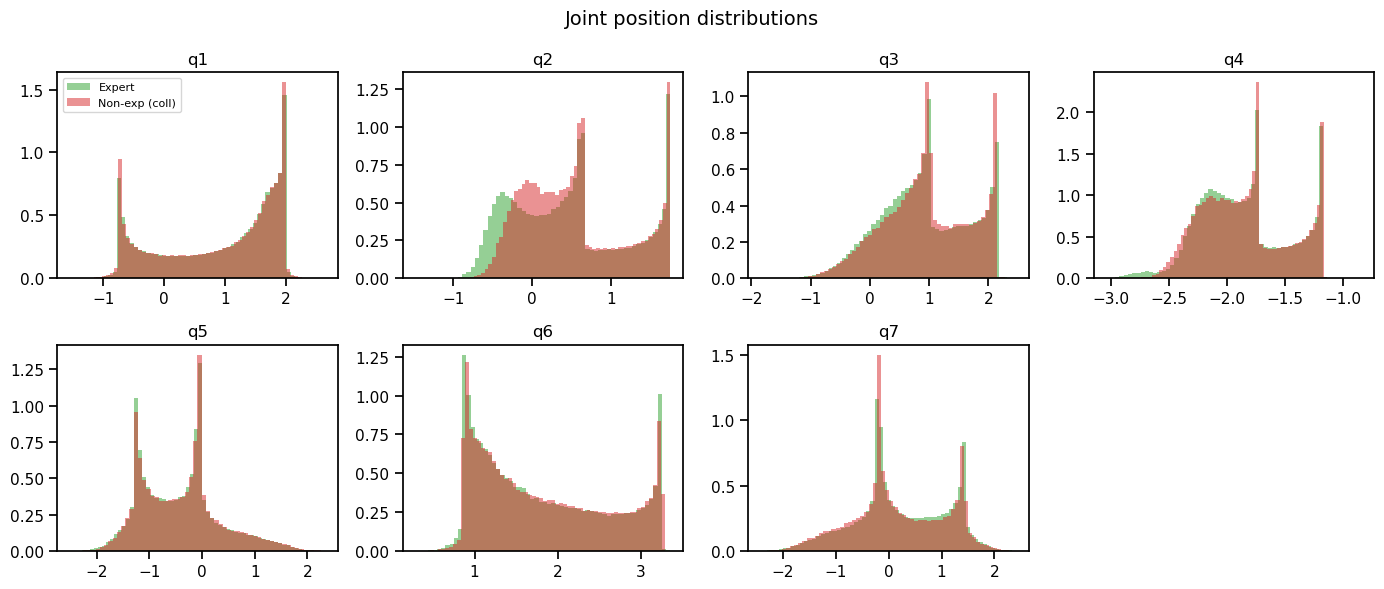

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()

for j in range(7):
    ax = axes[j]
    ax.hist(expert_free[:, :, j].ravel(), bins=60, alpha=0.5, density=True, label='Expert', color='tab:green')
    ax.hist(nonexp_coll[:, :, j].ravel(), bins=60, alpha=0.5, density=True, label='Non-exp (coll)', color='tab:red')
    ax.set_title(joint_names[j])
    if j == 0:
        ax.legend(fontsize=8)

axes[7].axis('off')
fig.suptitle('Joint position distributions', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Start and goal configurations

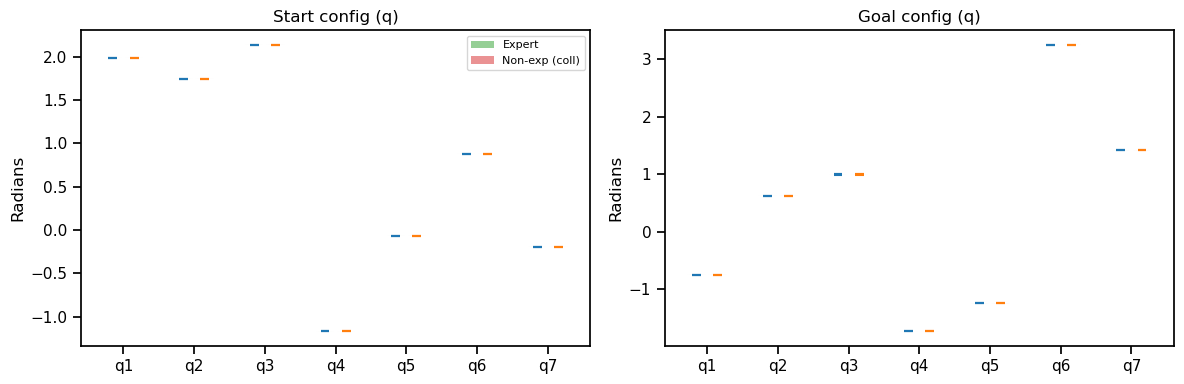

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, idx, title in [(axes[0], 0, 'Start config (q)'), (axes[1], -1, 'Goal config (q)')]:
    parts = ax.violinplot(
        [expert_free[:, idx, j] for j in range(7)],
        positions=np.arange(7) - 0.15, widths=0.25, showmedians=True
    )
    for pc in parts['bodies']:
        pc.set_facecolor('tab:green')
        pc.set_alpha(0.5)

    parts2 = ax.violinplot(
        [nonexp_coll[:, idx, j] for j in range(7)],
        positions=np.arange(7) + 0.15, widths=0.25, showmedians=True
    )
    for pc in parts2['bodies']:
        pc.set_facecolor('tab:red')
        pc.set_alpha(0.5)

    ax.set_xticks(range(7))
    ax.set_xticklabels(joint_names)
    ax.set_title(title)
    ax.set_ylabel('Radians')

# Manual legend
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor='tab:green', alpha=0.5, label='Expert'),
    Patch(facecolor='tab:red', alpha=0.5, label='Non-exp (coll)'),
], fontsize=8)
plt.tight_layout()
plt.show()

## 7. Trajectory smoothness

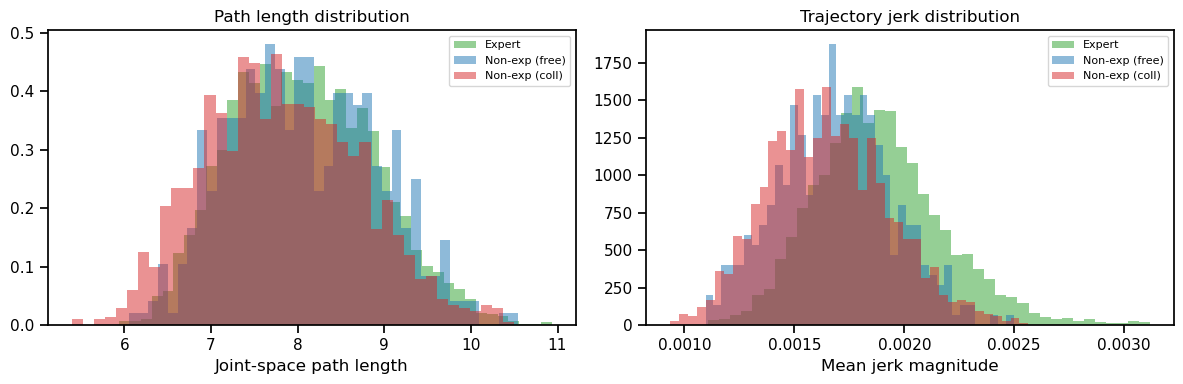

In [11]:
def path_length(trajs):
    """Total joint-space path length per trajectory."""
    diffs = np.diff(trajs[:, :, :7], axis=1)
    return np.sum(np.sqrt(np.sum(diffs**2, axis=2)), axis=1)

def jerk(trajs):
    """Mean jerk (3rd derivative) magnitude per trajectory."""
    d3 = np.diff(trajs[:, :, :7], n=3, axis=1)
    return np.mean(np.sqrt(np.sum(d3**2, axis=2)), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Path length
ax = axes[0]
for data, label, c in [(expert_free, 'Expert', 'tab:green'),
                        (nonexp_free, 'Non-exp (free)', 'tab:blue'),
                        (nonexp_coll, 'Non-exp (coll)', 'tab:red')]:
    ax.hist(path_length(data), bins=40, alpha=0.5, density=True, label=label, color=c)
ax.set_xlabel('Joint-space path length')
ax.set_title('Path length distribution')
ax.legend(fontsize=8)

# Jerk
ax = axes[1]
for data, label, c in [(expert_free, 'Expert', 'tab:green'),
                        (nonexp_free, 'Non-exp (free)', 'tab:blue'),
                        (nonexp_coll, 'Non-exp (coll)', 'tab:red')]:
    ax.hist(jerk(data), bins=40, alpha=0.5, density=True, label=label, color=c)
ax.set_xlabel('Mean jerk magnitude')
ax.set_title('Trajectory jerk distribution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. PCA embedding: expert vs non-expert

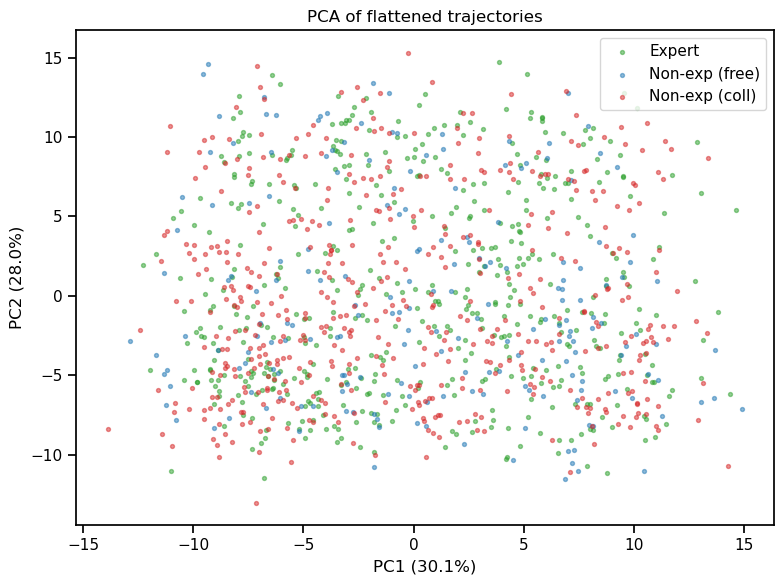

In [12]:
from sklearn.decomposition import PCA

# Flatten trajectories to (N, 64*14) for PCA
n_expert = min(500, expert_free.shape[0])
n_coll = min(500, nonexp_coll.shape[0])
n_nfree = min(200, nonexp_free.shape[0])

X = np.vstack([
    expert_free[:n_expert].reshape(n_expert, -1),
    nonexp_coll[:n_coll].reshape(n_coll, -1),
    nonexp_free[:n_nfree].reshape(n_nfree, -1),
])

labels = (['Expert'] * n_expert + ['Non-exp (coll)'] * n_coll + ['Non-exp (free)'] * n_nfree)

pca = PCA(n_components=2)
Z = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
color_map = {'Expert': 'tab:green', 'Non-exp (coll)': 'tab:red', 'Non-exp (free)': 'tab:blue'}
for lbl in ['Expert', 'Non-exp (free)', 'Non-exp (coll)']:
    mask = np.array(labels) == lbl
    ax.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, label=lbl, color=color_map[lbl])

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA of flattened trajectories')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Offline RL dataset structure

In [13]:
ds = torch.load(DATA_DIR / 'expert' / '0' / 'expert_offline_dataset.pt',
                map_location='cpu', weights_only=False)

print('Keys and shapes:')
for k, v in ds.items():
    if hasattr(v, 'shape'):
        print(f'  {k:20s} {str(v.shape):20s} dtype={v.dtype}')
    elif isinstance(v, dict):
        print(f'  {k:20s} dict with keys: {list(v.keys())}')

print(f'\nMeta: {ds["meta"]}')
print(f'\nReward range: [{ds["reward"].min():.4f}, {ds["reward"].max():.4f}]')
print(f'Terminal count: {ds["terminal"].sum().item()} / {len(ds["terminal"])}')

Keys and shapes:
  observation          torch.Size([6300, 7]) dtype=torch.float32
  next_observation     torch.Size([6300, 7]) dtype=torch.float32
  reward               torch.Size([6300])   dtype=torch.float32
  action               torch.Size([6300, 35]) dtype=torch.float32
  terminal             torch.Size([6300])   dtype=torch.uint8
  meta                 dict with keys: ['N', 'T', 'D', 'dt', 'action_type']

Meta: {'N': 100, 'T': 64, 'D': 14, 'dt': 0.078125, 'action_type': 'delta_pos'}

Reward range: [1.0000, 1.0000]
Terminal count: 100 / 6300


## 10. Pairwise joint correlations

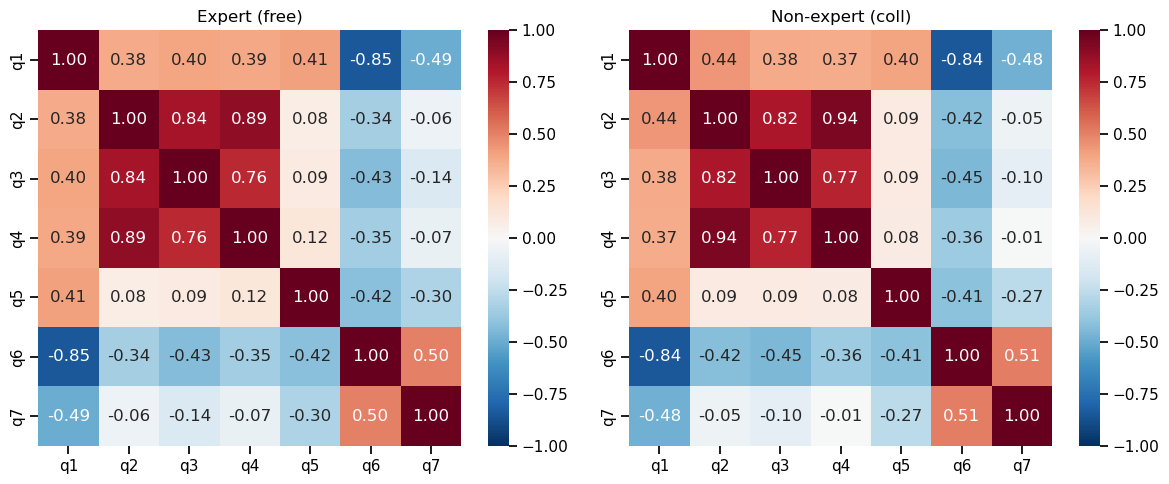

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in [(axes[0], expert_free, 'Expert (free)'),
                         (axes[1], nonexp_coll, 'Non-expert (coll)')]:
    flat = data[:, :, :7].reshape(-1, 7)
    corr = np.corrcoef(flat.T)
    sns.heatmap(corr, ax=ax, vmin=-1, vmax=1, cmap='RdBu_r', annot=True, fmt='.2f',
                xticklabels=joint_names, yticklabels=joint_names)
    ax.set_title(title)

plt.tight_layout()
plt.show()